### Data Preparation

## Chunking and Embeddings in RAG Systems

When working with long documents in a RAG system, the text must first be **preprocessed** so it can be stored and retrieved effectively.

---

## Why Chunking Is Necessary

Large documents are broken into **smaller chunks** before being added to a vector database.  
This is done because:

- Language models have limited context windows
- Smaller chunks are easier to retrieve accurately
- Fine-grained retrieval improves answer quality

Each chunk should be small enough to be processed independently, yet large enough to preserve meaning.

---

## From Chunks to Embeddings

After chunking:

- Each chunk is converted into an **embedding vector**
- The embedding captures the **semantic meaning** of the text
- These vectors are stored in a vector database

During retrieval, the system compares the embedding of a user’s question to stored embeddings and finds the **closest matches** based on vector distance.

---

## What Makes a Good Chunk

Chunking works best when each chunk:

- Contains **one clear piece of information**
- Can be understood **on its own**
- Does not rely heavily on surrounding text for context

If a chunk depends on previous or following sections, retrieval quality suffers—even if the embedding similarity is high.

---

## The Core Challenge

The main challenge in preprocessing is creating chunks that are both:
- **Semantically meaningful**
- **Context-independent**

A robust ingestion pipeline typically:
- Cleans raw text (removing noise, formatting artifacts, and irrelevant content)
- Splits documents at natural boundaries (paragraphs, sections, sentences)
- Produces chunks that stand alone and retrieve well

Good chunking is one of the most important factors in building accurate and reliable RAG systems.

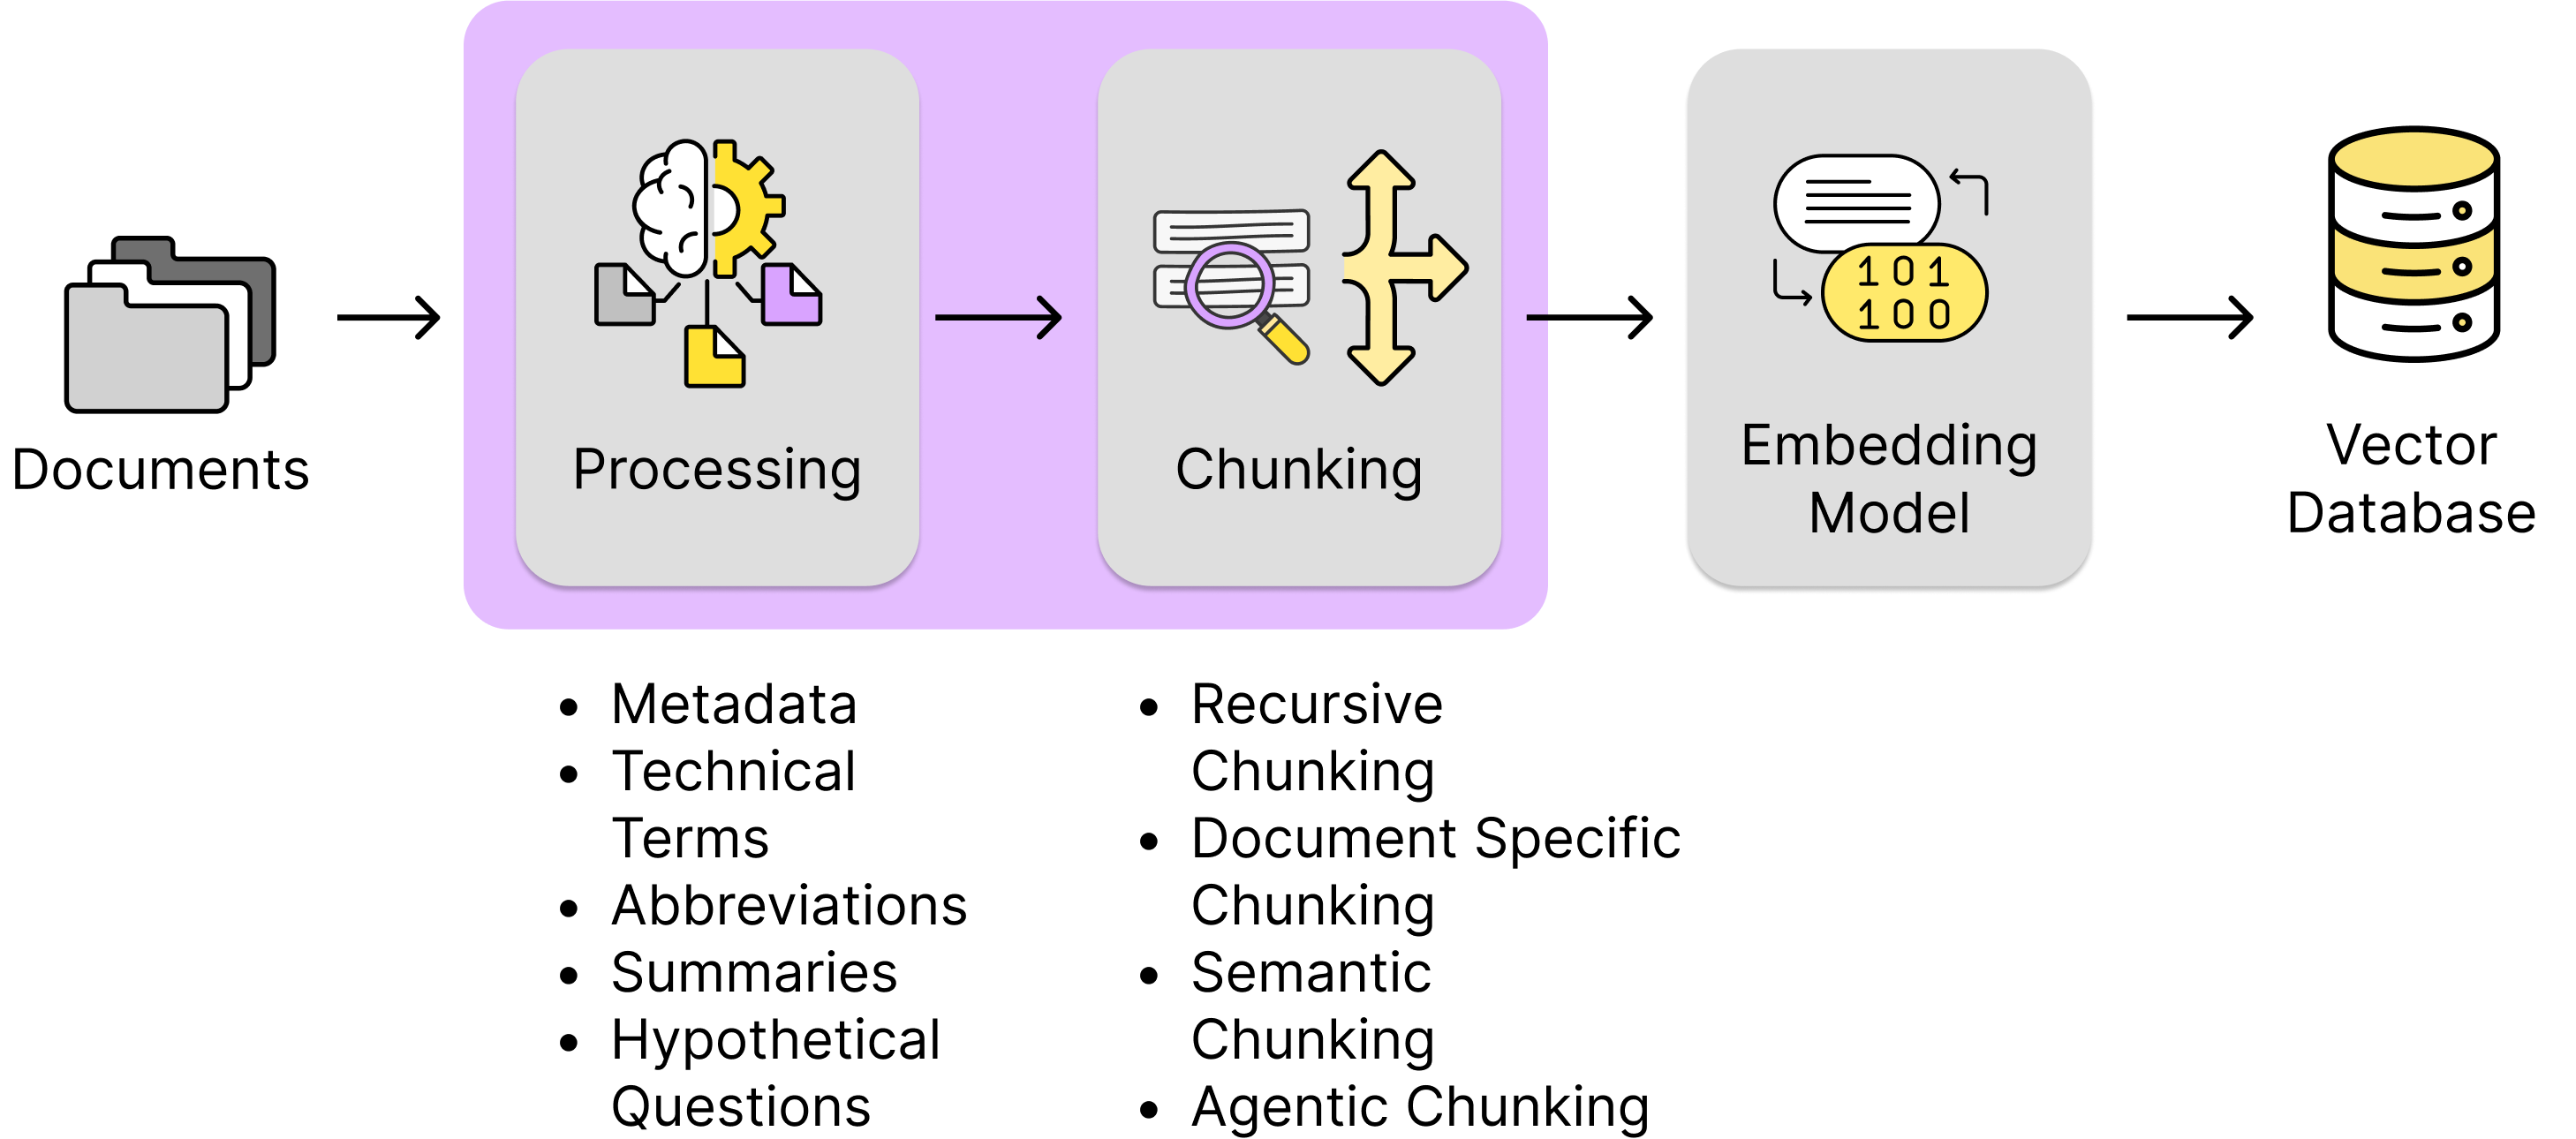

In [2]:
## The simplified RAG indexing pipeline including potential data processing techniques
from IPython.display import Image, display

display(Image(filename="images/rwpc_0401.png", width=500, height=500))

- Text preparation: Replace abbreviations and clean the text
- Metadata collection: Store page numbers, source, and author
- Text splitting: Apply character, recursive, semantic, or agentic chunking
- The goal is producing clear, unambiguous chunks that don’t require surrounding context.<br>
Store useful metadata with each chunk to enable filtering during retrieval, making the process both faster and more accurate.

### Adding Metadata to Enable Metadata Filtering

## Problem

You want to store **metadata alongside text chunks** in your vector store so that retrieval can apply **metadata-based filtering**.

Without metadata, retrieval relies only on semantic similarity.  
This makes it difficult to:
- Restrict results to specific documents or sources
- Filter by time, author, or document type
- Apply business or domain-specific constraints

---

## Solution

Store metadata together with each text chunk during ingestion.  
This enables **hybrid retrieval**, combining semantic similarity with structured filtering.

Metadata can come from three main sources.

---

## Metadata Extraction and Enrichment Stages

### 1. Extract Existing Document Metadata

Start with metadata that already exists in the source documents, such as:

- Author
- Title
- Creation or modification date
- Document type or source system

This information is often available in file headers, databases, or document management systems.

---

### 2. Add Computed Metadata

Next, compute additional metadata fields during ingestion, for example:

- File location or source path
- File size
- Page count
- Text length or token count
- Chunk index within the document

Computed metadata helps with debugging, ranking, filtering, and traceability.

---

### 3. (Optional) Generate Content-Based Metadata with an LLM

For specialized use cases, you can enrich chunks with **LLM-generated metadata**, such as:

- Topic labels
- Summaries
- Keywords or entities
- Sensitivity or compliance flags

This step analyzes the document text itself and adds higher-level semantic structure.

---

### 4. Store Metadata with Each Chunk

Finally, save the metadata **together with the text chunk and its embedding** in the vector store.

At query time, this allows you to:
- Filter results by metadata (e.g., date range, document type)
- Combine filters with vector similarity
- Improve precision and control over retrieval behavior

---

## Key Takeaway

👉 Metadata transforms a vector store from a pure similarity engine into a **controlled retrieval system**.  
Well-designed metadata enables better filtering, higher precision, and more reliable RAG pipelines.

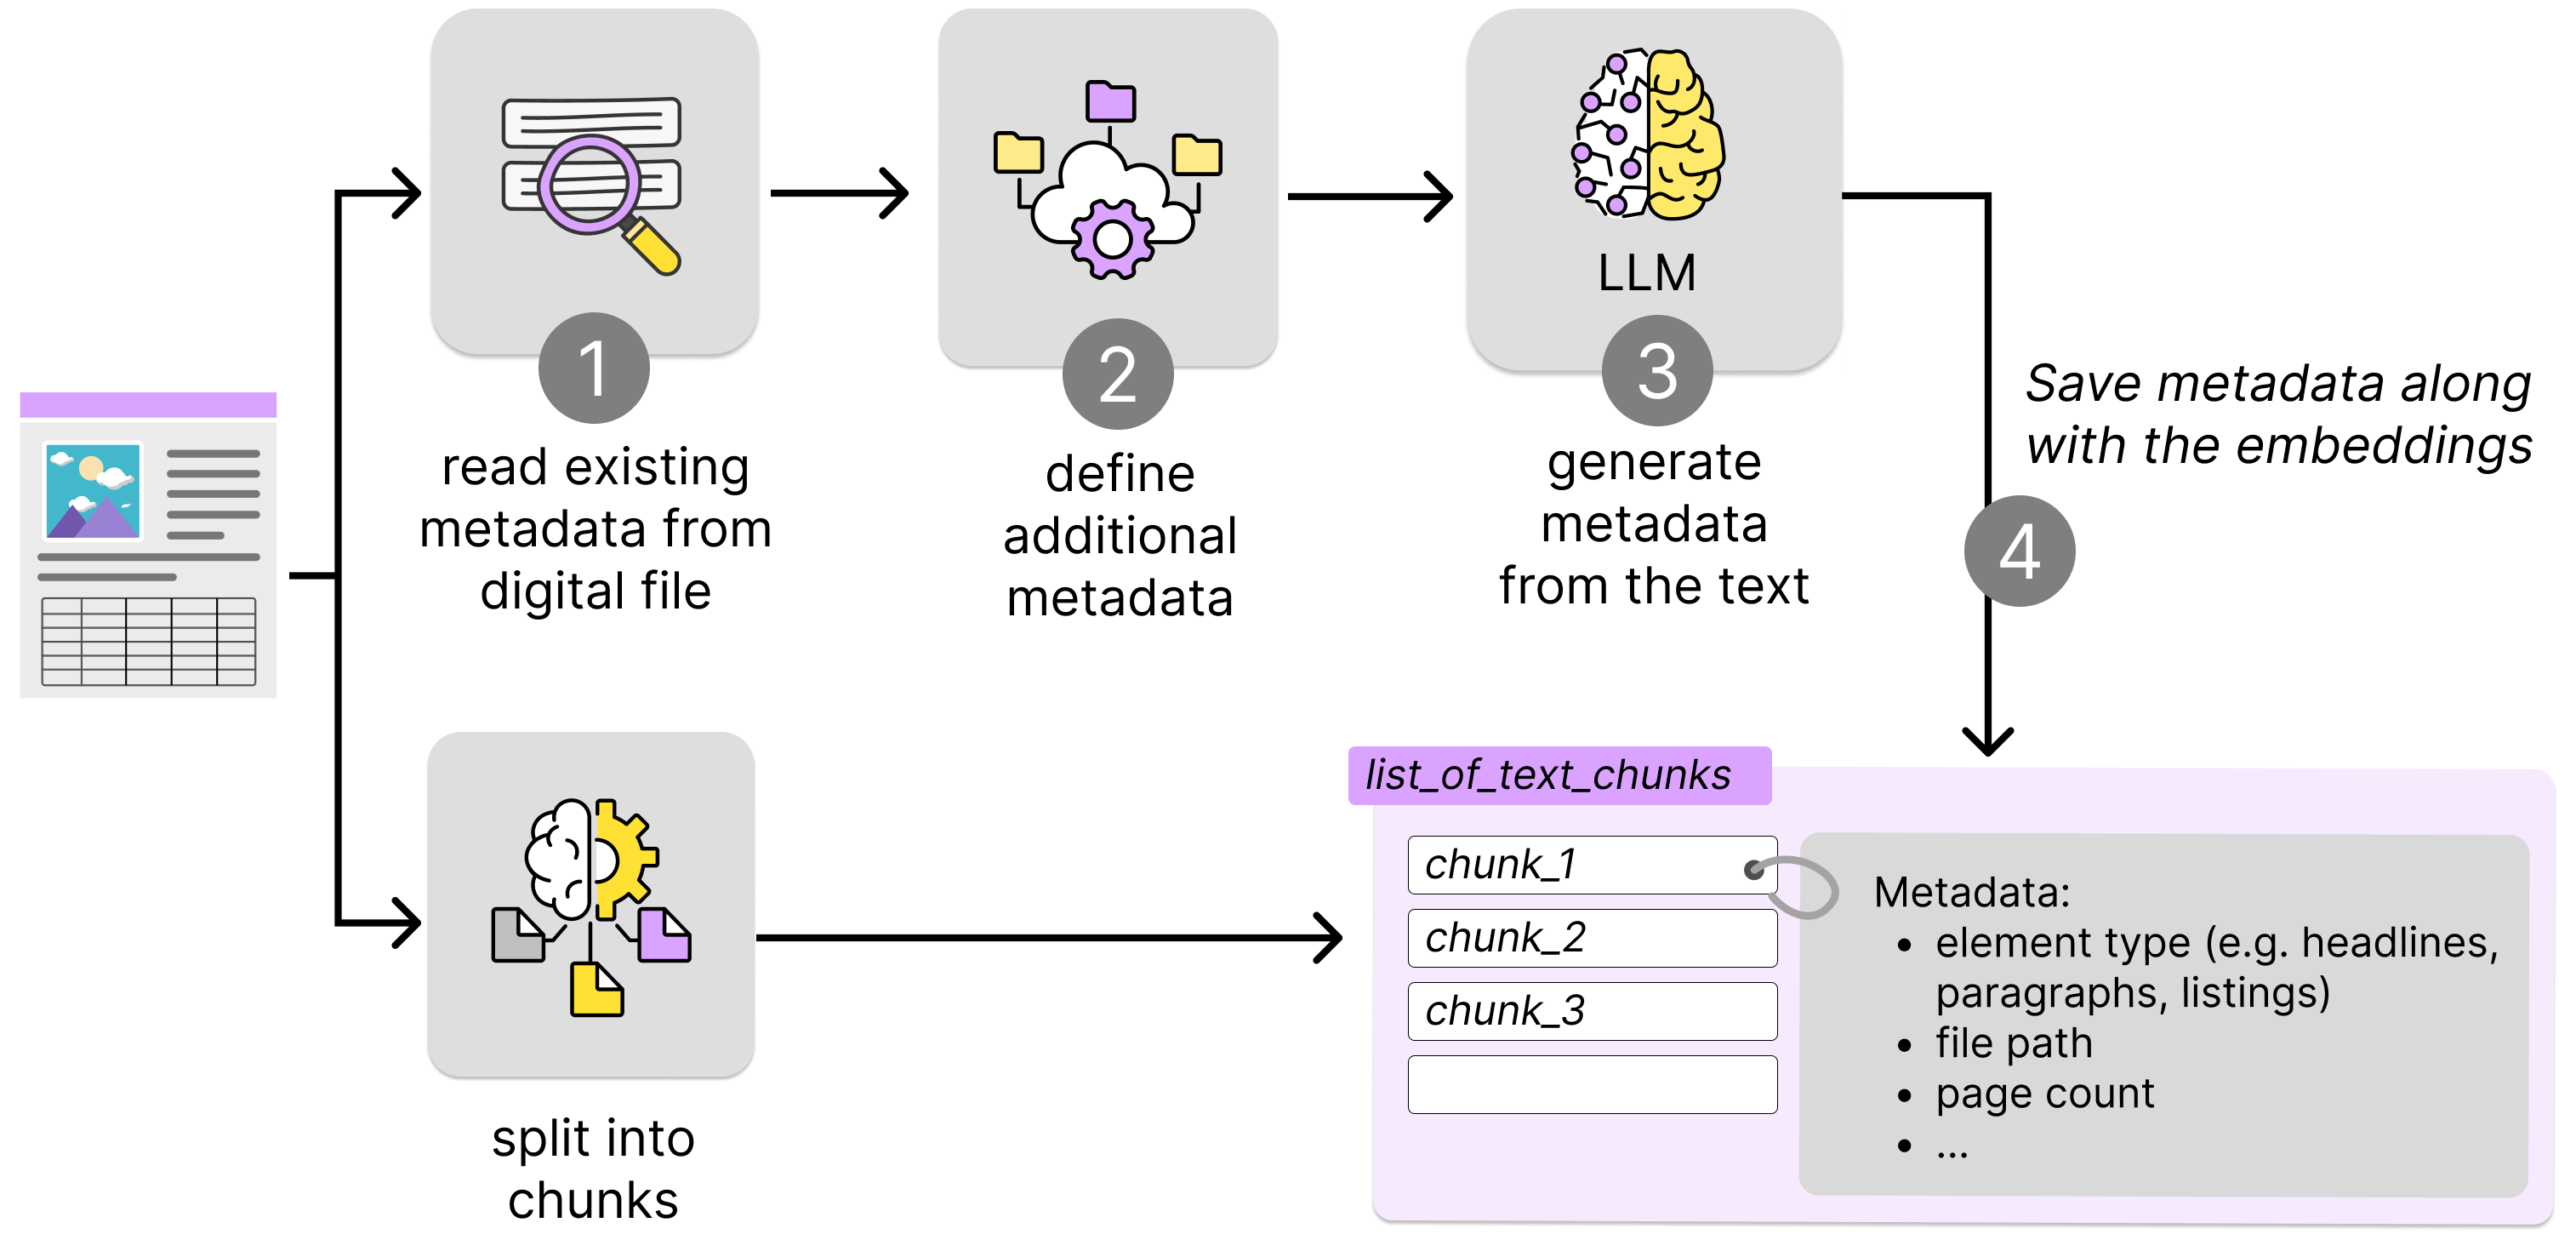

In [3]:
display(Image(filename="images/rwpc_0402.png", width=500, height=500))

In [4]:
# !pip install PyPDF2==3.0.1
# !pip install pandas==2.2.3
# !pip install pydantic==2.11.5
# !pip install openai==1.83.0
# !pip install matplotlib==3.10.3
# !pip install scikit-learn==1.6.1
# !pip install python-docx==1.1.2
# !pip install nltk==3.9.1
# !pip install langchain==0.3.25
# !pip install langchain_openai==0.3.21
# !pip install langchain-experimental==0.3.4
# !pip install python-dotenv==1.0.0

### Setting Up Sample Files

This notebook uses sample Word and PDF files.

When running the notebook on Google Colab, uncomment the code below to download the `datasets` directory from the Github repo.

In [2]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone --no-checkout https://github.com/polzerdo55862/RAG-with-Python-Cookbook.git
    %cd RAG-with-Python-Cookbook
    !git sparse-checkout init --cone
    !git sparse-checkout set datasets
    !git checkout
    !cp -r datasets /content/datasets
    print("\u2713 Datasets downloaded to /content/datasets")
else:
    print("\u26a0 Running locally. Using ../datasets/ directory")

Cloning into 'RAG-with-Python-Cookbook'...
remote: Enumerating objects: 1641, done.
remote: Counting objects: 100% (382/382), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 1641 (delta 253), reused 249 (delta 190), pack-reused 1259 (from 2)
Receiving objects: 100% (1641/1641), 42.80 MiB | 8.58 MiB/s, done.
Resolving deltas: 100% (937/937), done.
/content/RAG-with-Python-Cookbook
Your branch is up to date with 'origin/main'.
✓ Datasets downloaded to /content/datasets


### Setting Up API Secrets

If you run this code in Google Colab, save your OpenAI API key in the colab secrets and load it to the environmental variables.

In [4]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

## Metadata Extraction and Filtering

In [7]:
import PyPDF2
import os

file_path = "../datasets/pdf_files/attention_is_all_you_need_paper.pdf"

with open(file_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)
    metadata = reader.metadata

    text = ""
    for page in reader.pages:
        text += page.extract_text()
metadata


{'/Author': '',
 '/CreationDate': 'D:20240410211143Z',
 '/Creator': 'LaTeX with hyperref',
 '/Keywords': '',
 '/ModDate': 'D:20240410211143Z',
 '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
 '/Producer': 'pdfTeX-1.40.25',
 '/Subject': '',
 '/Title': '',
 '/Trapped': '/False'}

In [9]:
metadata_ext = dict(metadata)
metadata_ext["page_count"] = len(reader.pages)
metadata_ext["file_size"] = os.path.getsize(file_path)
metadata_ext["file_name"] = os.path.basename(file_path)
metadata_ext["file_path"] = file_path
metadata_ext["text_length"] = len(text)
metadata_ext


{'/Author': '',
 '/CreationDate': 'D:20240410211143Z',
 '/Creator': 'LaTeX with hyperref',
 '/Keywords': '',
 '/ModDate': 'D:20240410211143Z',
 '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
 '/Producer': 'pdfTeX-1.40.25',
 '/Subject': '',
 '/Title': '',
 '/Trapped': '/False',
 'page_count': 15,
 'file_size': 2215244,
 'file_name': 'attention_is_all_you_need_paper.pdf',
 'file_path': '../datasets/pdf_files/attention_is_all_you_need_paper.pdf',
 'text_length': 39472}

In [11]:
from pydantic import BaseModel
from openai import OpenAI

client = OpenAI()

class AuthorContact(BaseModel):
    name: str
    company: str
    email: list[str]

class Contacts(BaseModel):
    entries: list[AuthorContact]

system_message = """Extract the contact information of all authors."""

response = client.beta.chat.completions.parse(
    model="gpt-5-mini",
    messages=[
        {
            "role": "system",
            "content": system_message,
        },
        {
            "role": "user",
            "content": text,
        },
    ],
    response_format=Contacts,
)

author_contacts = response.choices[0].message.parsed

metadata_ext_llm = dict(metadata_ext)
metadata_ext_llm["author_contacts"] = author_contacts
metadata_ext_llm


{'/Author': '',
 '/CreationDate': 'D:20240410211143Z',
 '/Creator': 'LaTeX with hyperref',
 '/Keywords': '',
 '/ModDate': 'D:20240410211143Z',
 '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
 '/Producer': 'pdfTeX-1.40.25',
 '/Subject': '',
 '/Title': '',
 '/Trapped': '/False',
 'page_count': 15,
 'file_size': 2215244,
 'file_name': 'attention_is_all_you_need_paper.pdf',
 'file_path': '../datasets/pdf_files/attention_is_all_you_need_paper.pdf',
 'text_length': 39472,
 'author_contacts': Contacts(entries=[AuthorContact(name='Ashish Vaswani', company='Google Brain', email=['avaswani@google.com']), AuthorContact(name='Noam Shazeer', company='Google Brain', email=['noam@google.com']), AuthorContact(name='Niki Parmar', company='Google Research', email=['nikip@google.com']), AuthorContact(name='Jakob Uszkoreit', company='Google Research', email=['usz@google.com']), AuthorContact(name='Llion Jones', company='Google Research', email

## How Metadata Filtering Works in Vector Search

Metadata filtering improves retrieval quality by **narrowing the search space before semantic similarity is calculated**.

Instead of comparing a query against *all* vectors in the database, the vector store:

1. **Applies metadata constraints first**  
   (for example: `author == "Smith"` or `date >= 2023`)

2. **Runs semantic similarity search only on the filtered subset**

By reducing the candidate set, the system avoids retrieving text that is
semantically similar but **contextually irrelevant**.

---

## Why Metadata Filtering Matters

Semantic similarity alone can be misleading.  
Different documents often use the same words to mean different things.

Metadata filtering helps:
- Reduce false positives
- Improve precision
- Make retrieval behavior more predictable and controllable

---

## When to Use Metadata Filtering

Metadata filtering is especially useful when your data naturally falls into **distinct buckets** and users usually care about **one bucket at a time**.

### Common Scenarios

- **Multiple departments in one index**  
  Example: HR, engineering, and finance documents stored together  
  → Filter to `department = "engineering"` before searching

- **Time-based document collections**  
  Example: Content indexed across multiple years or quarters  
  → Filter to `year = 2024` when the user asks about last year

- **Mixed content types**  
  Example: Manuals, support tickets, and emails  
  → Filter to `source = "manual"` to avoid pulling informal support chatter

- **Overlapping vocabulary**  
  Example: The word *“release”* appears in:
  - Product documentation
  - Press releases  
  → Filter by document type to disambiguate meaning

---

## Key Takeaway

👉 Use metadata filtering to **limit what the vector search can see**  
before asking, “Which of these is most similar?”

This combination of **structured filtering + semantic similarity**
is one of the most effective ways to improve RAG retrieval accuracy.

In [ ]:
## How two semantically similar information sets can be contradictory

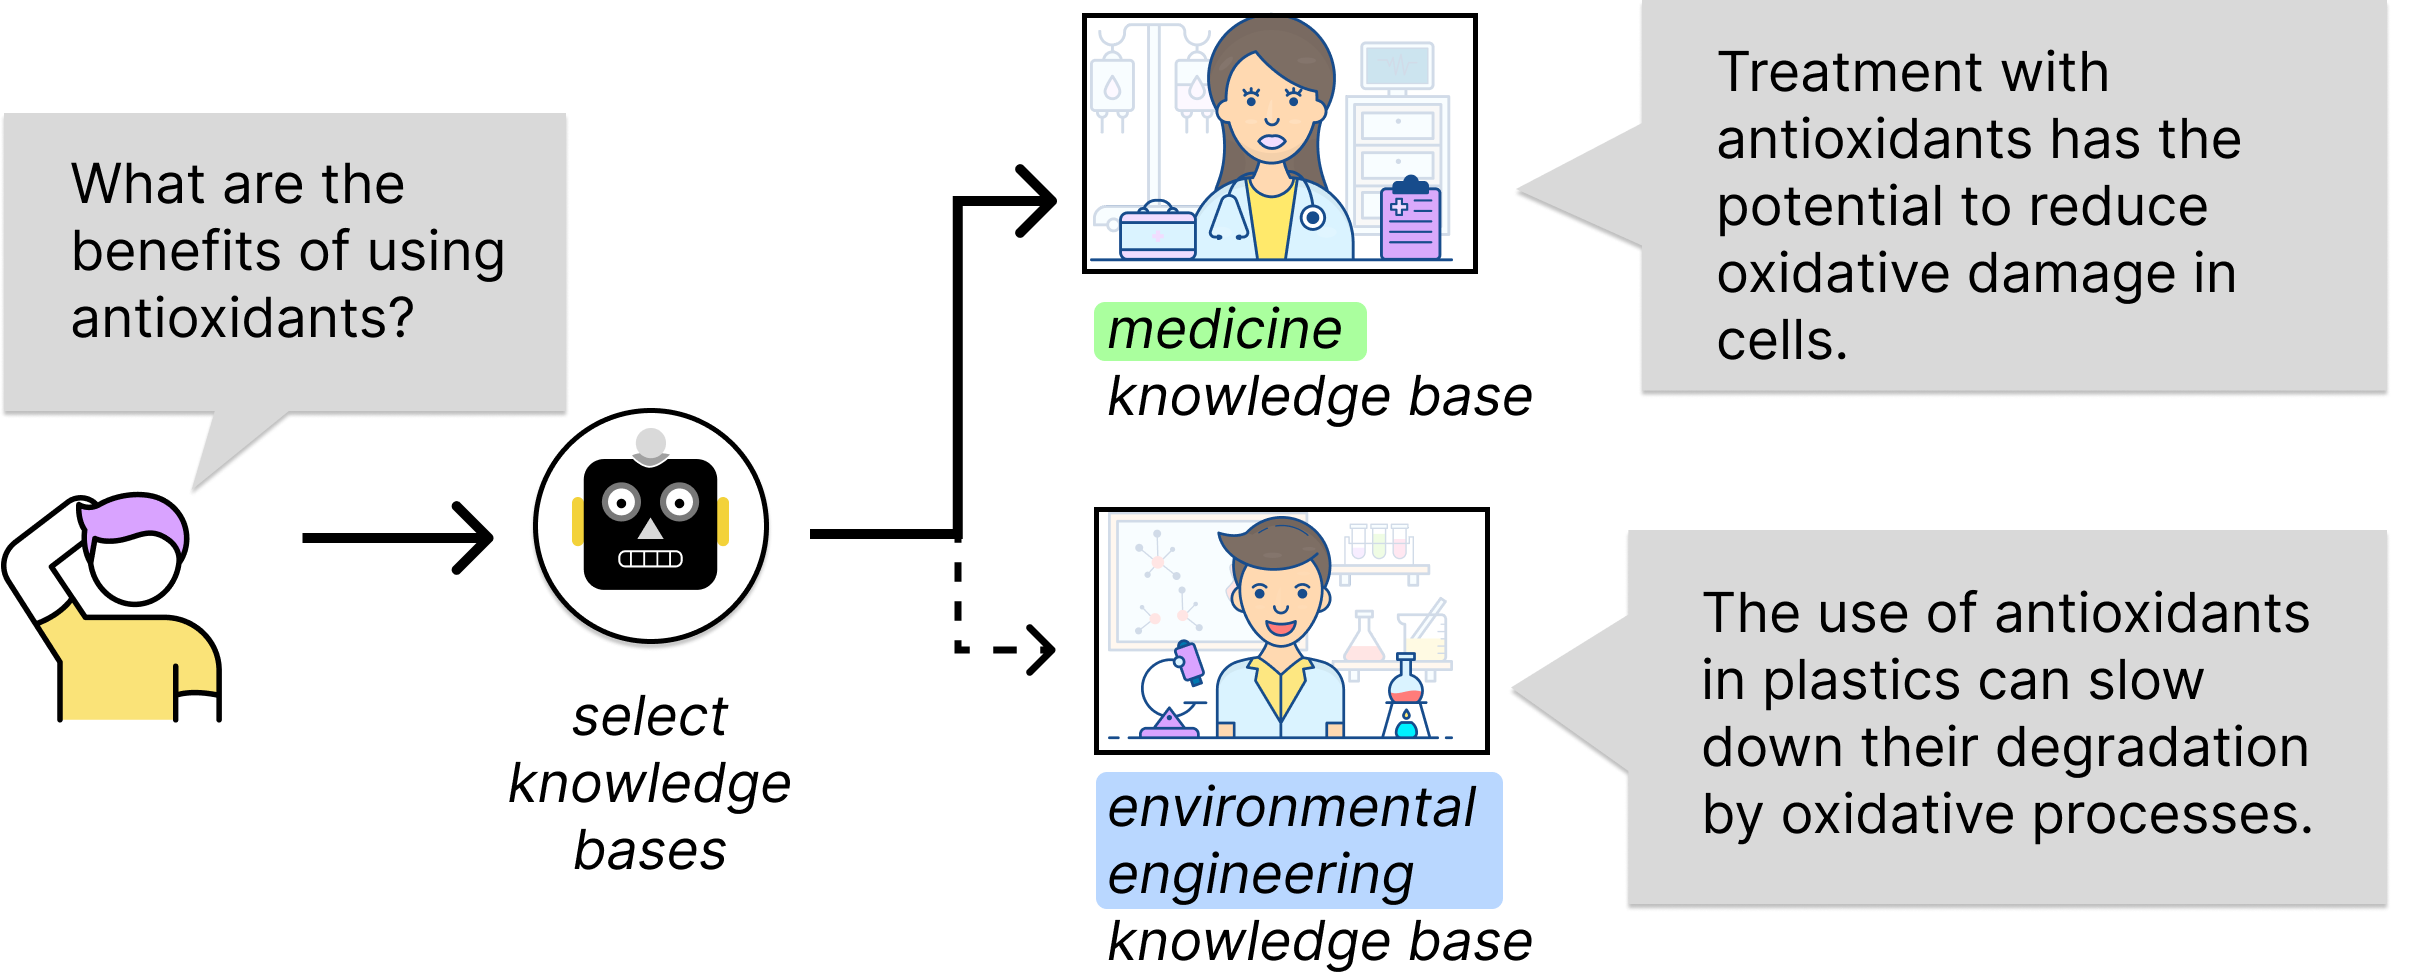

In [6]:
display(Image(filename="images/rwpc_0406.png", width=500, height=500))

### Enhancing Data Quality by Replacing Abbreviations and Technical Terms

#### Problem
You want every text chunk in your vector store to be self-explanatory so it can be understood as a standalone piece of information.

#### Solution
Use regular expressions and LLMs to expand abbreviations and clarify technical terms before generating embeddings. This makes text chunks self-explanatory when stored as standalone pieces.

## Data Quality Enhancement: Abbreviation Expansion

###
### Problem
You want every text chunk in your vector store to be self-explanatory so it can be understood as a standalone piece of information.

### Solution
Use regular expressions and LLMs to expand abbreviations and clarify technical terms before generating embeddings. This makes text chunks self-explanatory when stored as standalone pieces.

First, install the OpenAI SDK:

In [13]:
import re

abbreviations_dict = {
    "NLP": "Natural Language Processing",
    "RNN": "Recurrent Neural Network",
    "LSTM": "Long Short-Term Memory",
    "GRU": "Gated Recurrent Unit",
    "TF": "Transformer",
    "MHA": "Multi-Head Attention",



    
    "FFN": "Feed-Forward Network",
}

file_path = "../datasets/text_files/blog_post_transformers.txt"
with open(file_path, "r") as file:
    text = file.read()

# Replace abbreviations in the text
for abbr, full_form in abbreviations_dict.items():
    text = re.sub(rf"\b{abbr}\b", f"{full_form} ({abbr})", text)

text


'Unveiling Transformer Models: A Revolution in ML\n\nIn the realm of ML and DL, few advancements have reshaped the field as profoundly as Transformer models. First introduced in the seminal paper "Attention Is All You Need," Transformer models have become the backbone of modern Natural Language Processing (NLP) and are extending their reach into CV and beyond.\n\nThe Challenges Before Transformers\n\nPrior to Transformers, models like RNNs, LSTMs, and GRUs were the primary tools for sequential data. While effective, these architectures faced significant challenges:\n\nSequential Computation: Processing one step at a time limited their ability to leverage parallelism, making training slower.\n\nLong-Range Dependencies: Understanding relationships between distant elements in a sequence was difficult.\n\nVanishing Gradients: Gradients diminished over long sequences, hampering effective learning.\n\nEnter Transformers, which bypass these limitations with a novel approach: SA.\n\nThe Anatom

In [14]:
import os
from openai import OpenAI

file_path = "../datasets/text_files/EMEA_drives_revenue.txt"

with open(file_path, "r") as file:
    text = file.read()

prompt = f"""
    The text below contains a financial report including a lot of
    abbreviations and technical terms from the finance domain.
    Please replace the abbreviations with their full forms and
    provide a brief explanation of the technical terms, so the
    whole text gets easier to read and understandable for everyone.

    Make sure it's easy enough, so that a 10-year-old school kid could
    understand it.

    Often used abbreviations are:
    - EMEA: Europe, Middle East, and Africa
    - BD: Business Development
    - YoY: Year-over-Year
    - APAC: Asia-Pacific

    Text:
    {text}
    """.strip()

client = OpenAI()
chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": prompt,
        }
    ],
    model="gpt-5.2",
)

enhanced_text = chat_completion.choices[0].message.content
enhanced_text


'**Europe, Middle East, and Africa (EMEA) Drives Big Sales Jump in Quarter 2 of 2019 (Q2 2019): Business Development (BD) Team Delivers Strong Year-over-Year (YoY) Growth**\n\nIn **Quarter 2 of 2019 (Q2 2019)**, the **Business Development (BD)** team helped the company sell a lot more than before. The **Europe, Middle East, and Africa (EMEA)** region was the biggest reason for this growth. Compared with the same time last year, sales grew by as much as **2.3x** (that means **about 2.3 times as much**, or **more than double**).\n\n---\n\n## Key Highlights (in simpler words)\n\n- **Europe, Middle East, and Africa (EMEA) was strongest:**  \n  Sales in **20 different countries** across EMEA made Quarter 2 of 2019 very successful.\n\n- **Top contributing countries:**  \n  The countries that added the most to total sales in Quarter 2 of 2019 were:  \n  - **United States (US): 28%**  \n  - **Spain: 20%**  \n  - **India: 15%**  \n  - **Norway: 11%**\n\n- **Year-over-Year (YoY) growth:**  \n  T

In [15]:
# write enhanced_text to a new .txt file
output_file_path = "../datasets/text_files/EMEA_drives_revenue_enhanced.txt"
with open(output_file_path, "w") as file:
    file.write(enhanced_text)

## Expanding Abbreviations in RAG Chunking

When abbreviations are expanded and technical terms are clarified, each text chunk becomes **understandable on its own**.  
This matters because RAG systems retrieve chunks **in isolation**.

During retrieval:
- The embedding model only sees the words inside a chunk
- It has no access to surrounding context
- Vague or abbreviated terms provide less semantic signal

For example, **“NLP”** is far less informative than  
**“Natural Language Processing (NLP)”**.

Users often search with short or mixed-language queries, and embeddings work better when **both the abbreviation and the expanded form** appear in the text.

---

## Why This Works

Expanding abbreviations improves retrieval quality for several reasons:

- Embeddings built from **expanded terms** contain richer semantic meaning than acronyms alone  
- Queries like *“NLP models”*, *“language models”*, or *“text understanding”* still match chunks that include *Natural Language Processing*  
- Retrieved chunks are easier for the LLM to interpret **without guessing** what an acronym means  

This reduces ambiguity at both the retrieval and generation stages.

---

## When to Use Abbreviation Expansion

This technique is especially helpful for:

- Technical documents filled with acronyms  
- Financial or legal reports that rely on shorthand  
- Medical or clinical text  
- Any document intended for readers **outside the original expert audience**

---

## When Not to Use It

Abbreviation expansion is not always appropriate. Avoid it when:

- Abbreviations are the standard and universally understood form  
  (for example, *HTTP* in web development)

- Preprocessing very large collections would be too expensive  

- Documents must be ingested **in real time** with extremely low latency  

---

## Key Takeaway

👉 Expand abbreviations when it improves clarity and semantic signal.  
The goal is to make each chunk **self-contained**, searchable, and easy for both embedding models and LLMs to interpret.

### Improving Search Accuracy by Creating Hypothetical Questions for Text Chunks

### Problem
You want to improve retriever quality by comparing the user’s question to hypothetical questions derived from text chunks, instead of comparing it directly to the text chunks.

### Solution
the preprocessing and indexing steps, as well as retrieval at runtime in the RAG app.

Before indexing the data, you need to:

Load the data and split it into chunks.

Iterate over the chunks and generate at least one hypothetical question per text chunk.

Generate embeddings for each hypothetical question.

Store the hypothetical questions and their embeddings in the database.

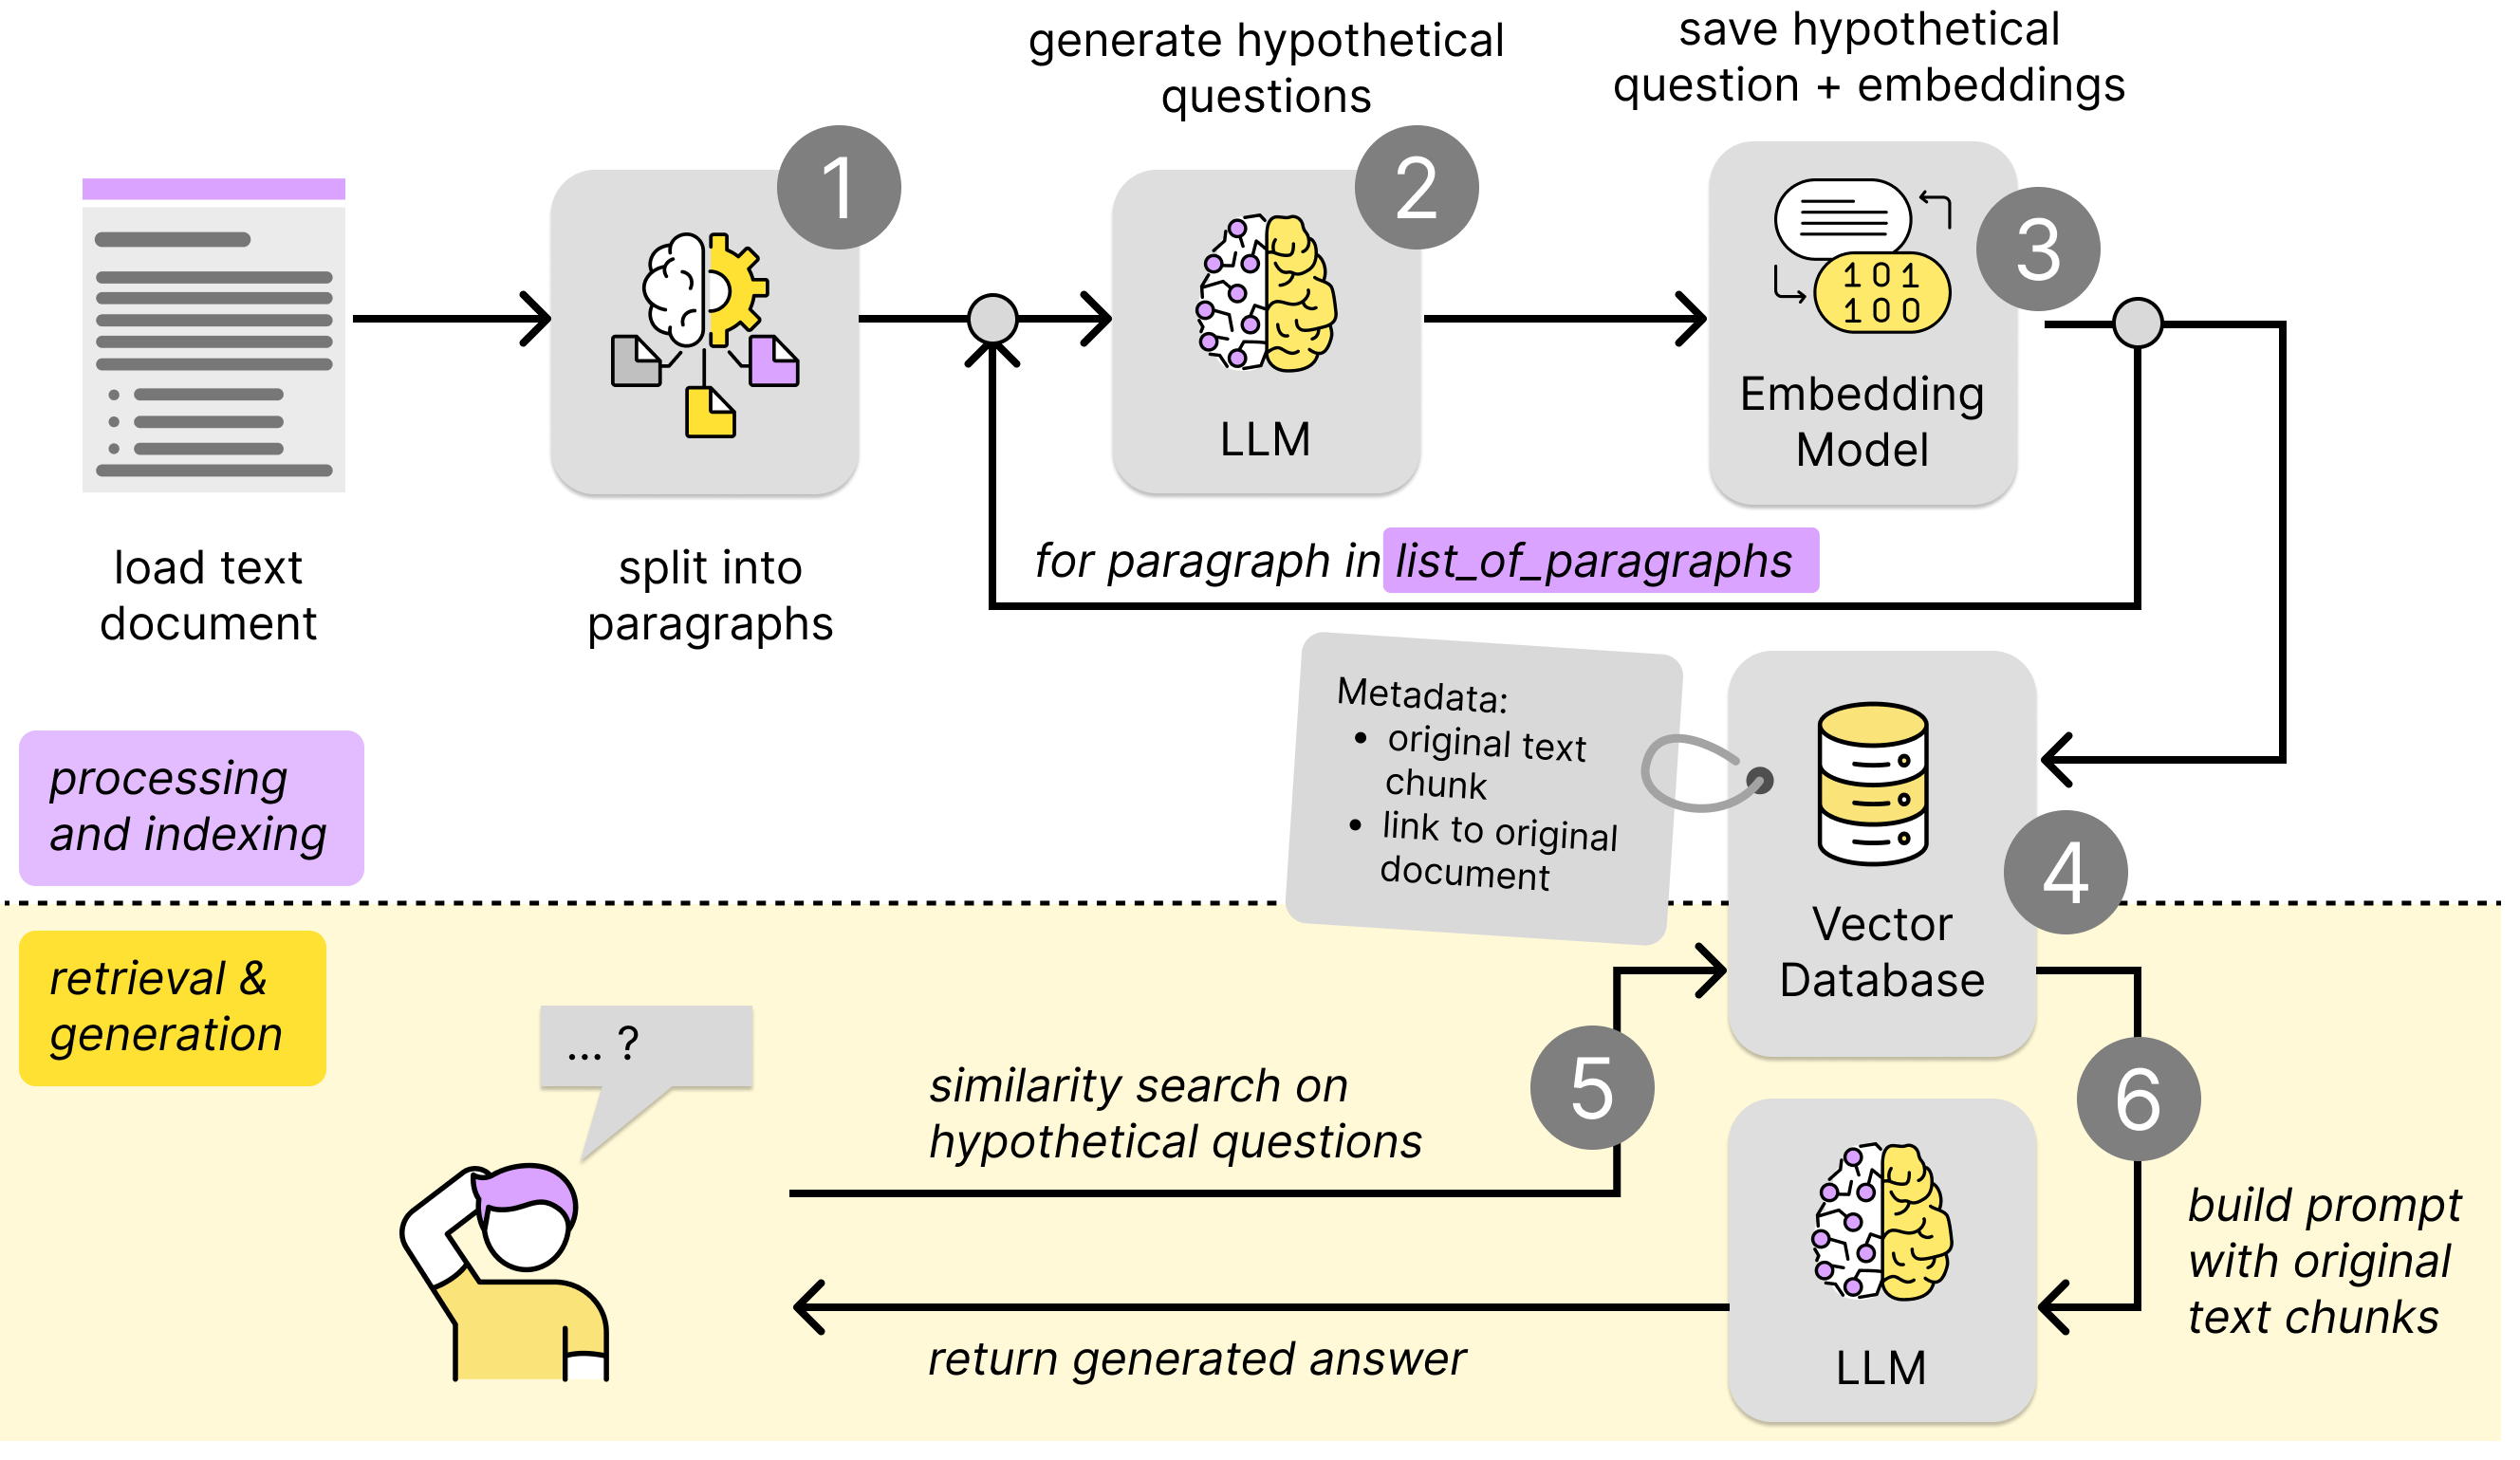

In [9]:
display(Image(filename="images/rwpc_0409.png", width=500, height=500))

Each hypothetical question links back to its original text chunk. During runtime of the RAG app, the retriever searches the hypothetical questions, but typically the underlying text chunks are what you pass to the LLM, so the model receives the full context rather than only the derived hypothetical questions.

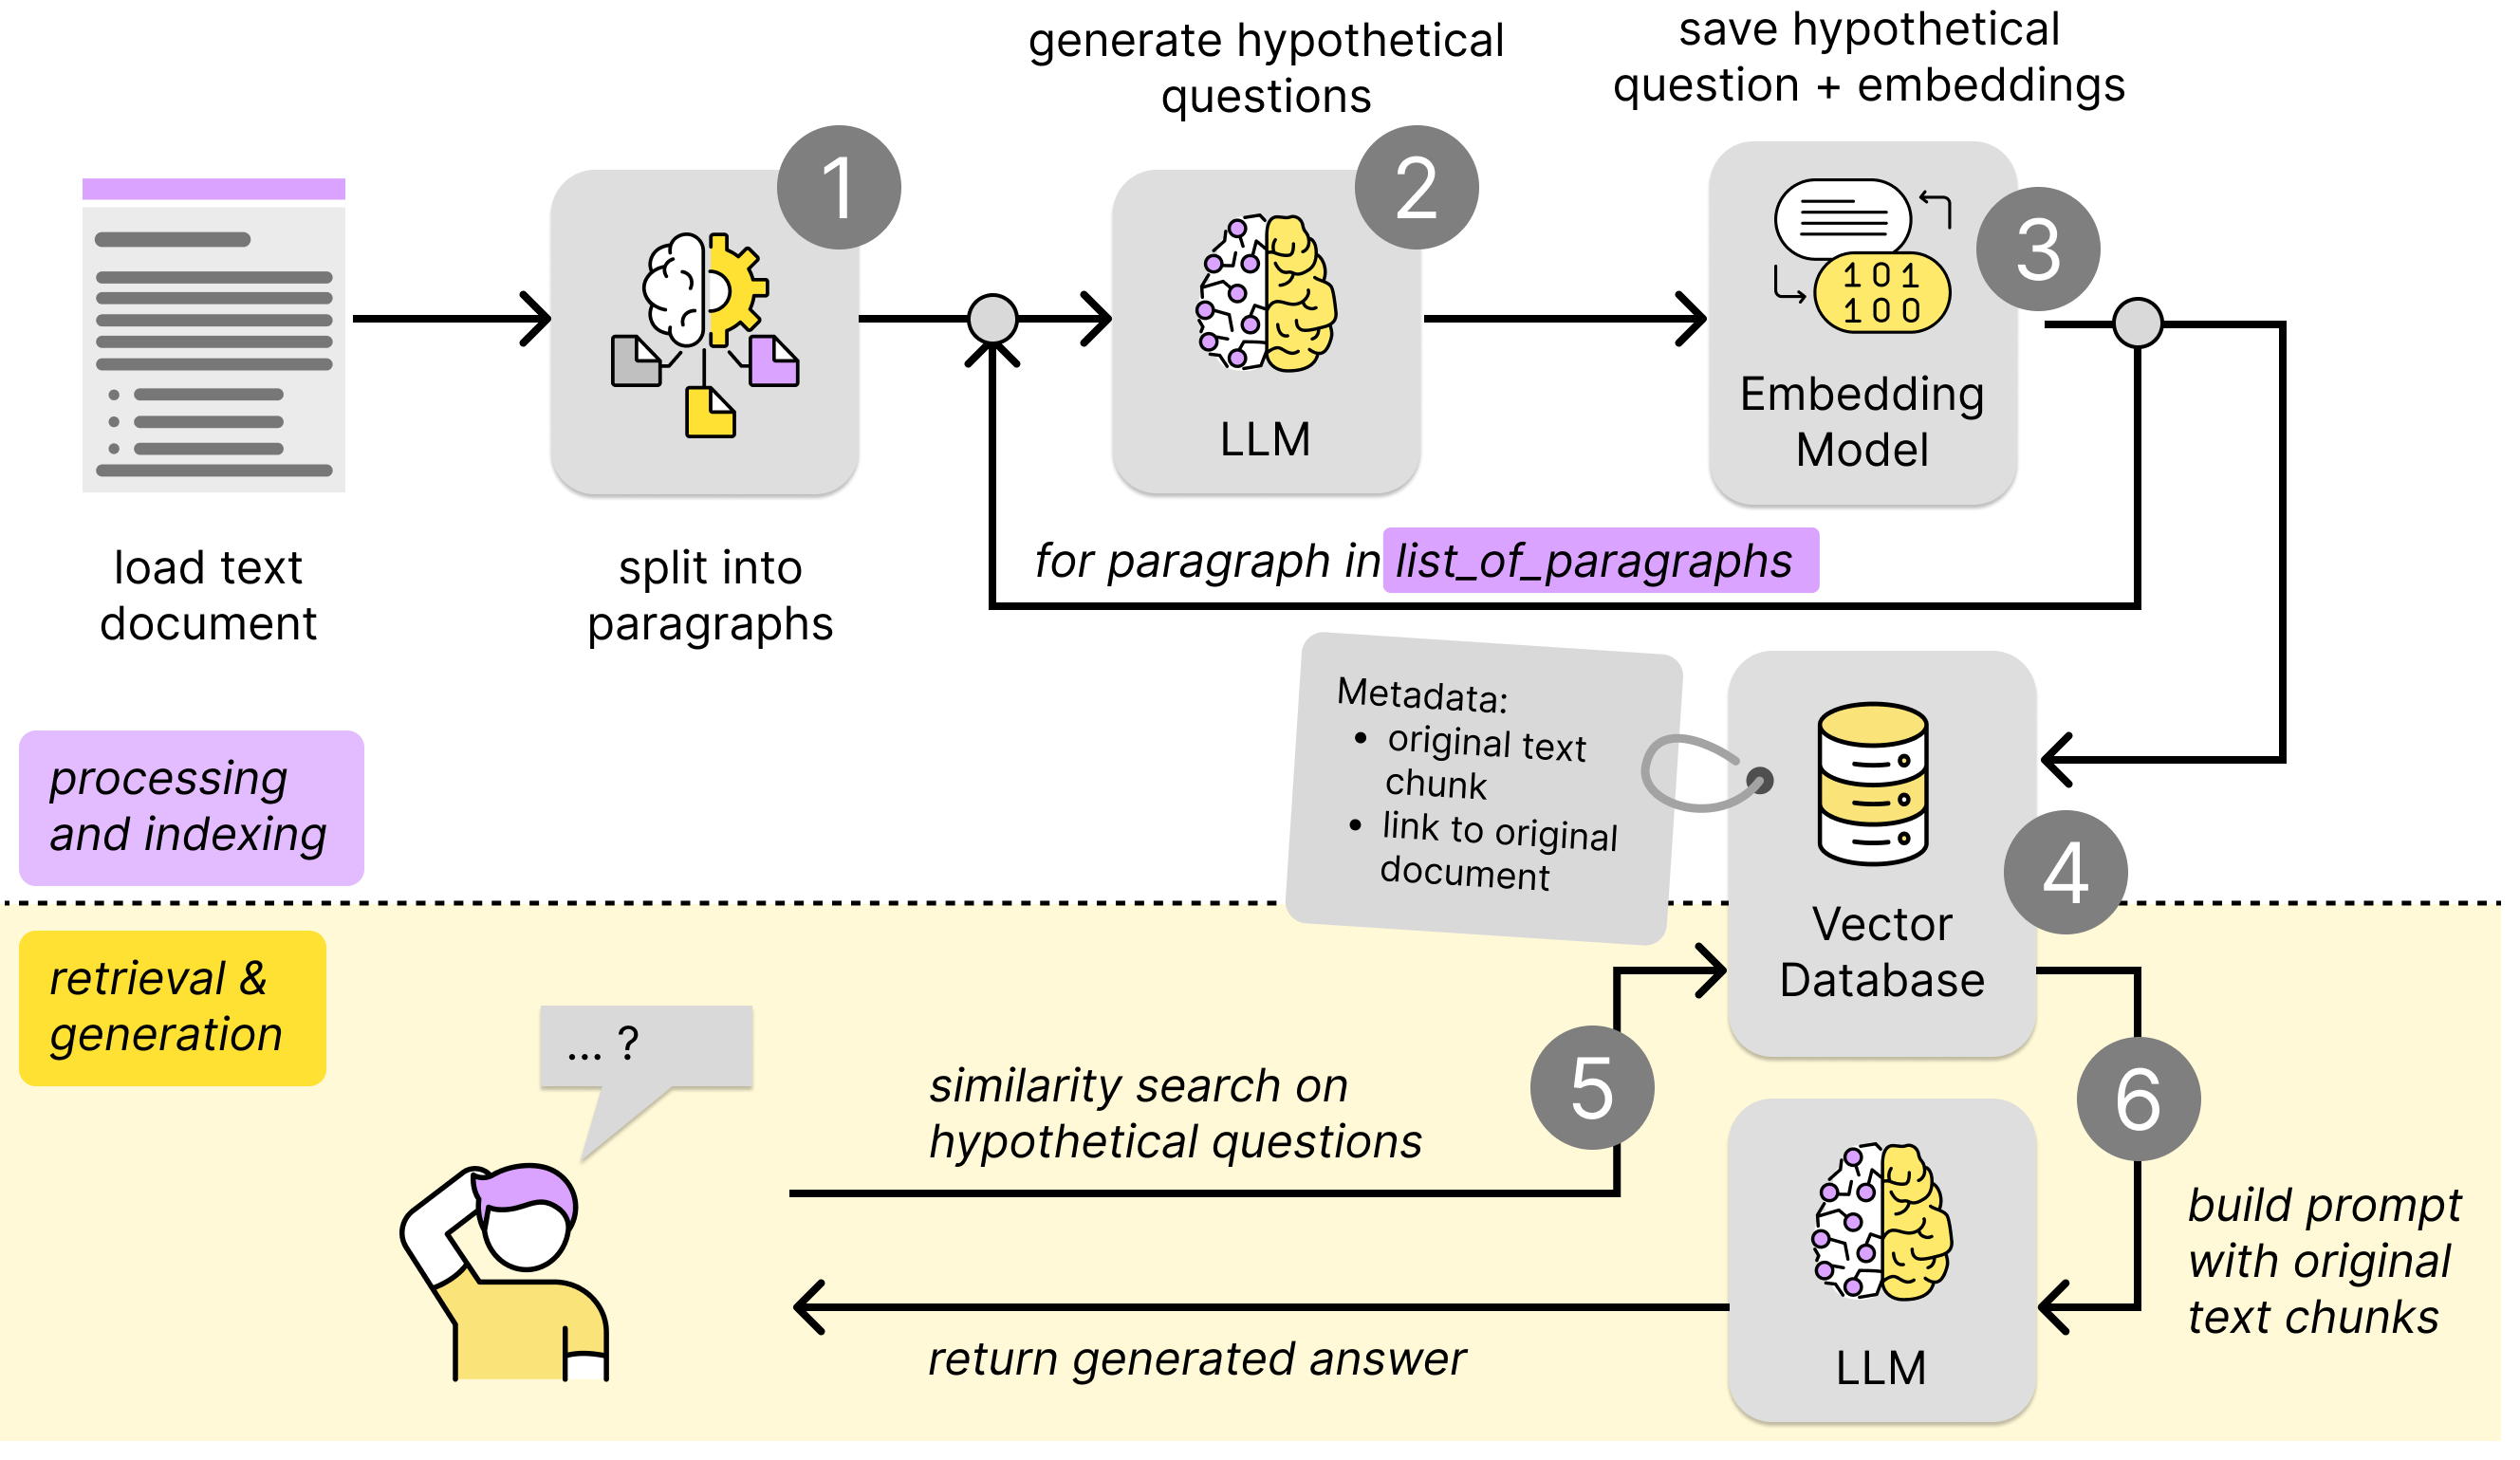

In [12]:
display(Image(filename="images/rwpc_0.png", width=500, height=500))

## Hypothetical Question Embedding for Enhanced Retrieval

In [17]:
import PyPDF2

file_path = "../datasets/pdf_files/AI_in_Factories_Discussion_Cleaned.pdf"

with open(file_path, "rb") as file:
    # Create PDF reader object
    reader = PyPDF2.PdfReader(file)

    # Extract text from all pages
    text = ""
    for page in reader.pages:
        text += page.extract_text()

text


"Discussion: Pros and Cons of AI in Factories\nAlex: Hey Sam, I read this article about AI revolutionizing factory work. It sounds amazing! Did you \nknow that AI-powered predictive maintenance can reduce downtime by up to 30%? Imagine how\nmuch that could improve productivity.\nSam: Yeah, I've read about that too. AI definitely has potential, but I feel like there's more to \nconsider than just efficiency. For instance, one study found that automation and AI could displace \nup to 20 million manufacturing jobs worldwide by 2030.\nAlex: That's a fair point, but couldn't companies invest in reskilling programs? According to a report \nby the World Economic Forum, 50% of all employees will need reskilling by 2025 due to the\nadoption of \nnew technologies. It's not impossible-it's about prioritizing it.\nSam: True, but not every company has the resources to reskill workers effectively. And there's also \nthe question of cost. AI implementation is expensive-customized AI solutions for fac

In [19]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    separators=[
        "\n\n",
    ],
)

text_chunks = text_splitter.split_text(text)
text_chunks

["Discussion: Pros and Cons of AI in Factories\nAlex: Hey Sam, I read this article about AI revolutionizing factory work. It sounds amazing! Did you \nknow that AI-powered predictive maintenance can reduce downtime by up to 30%? Imagine how\nmuch that could improve productivity.\nSam: Yeah, I've read about that too. AI definitely has potential, but I feel like there's more to \nconsider than just efficiency. For instance, one study found that automation and AI could displace \nup to 20 million manufacturing jobs worldwide by 2030.\nAlex: That's a fair point, but couldn't companies invest in reskilling programs? According to a report \nby the World Economic Forum, 50% of all employees will need reskilling by 2025 due to the\nadoption of \nnew technologies. It's not impossible-it's about prioritizing it.\nSam: True, but not every company has the resources to reskill workers effectively. And there's also \nthe question of cost. AI implementation is expensive-customized AI solutions for fa

In [20]:
import textwrap
from openai import OpenAI
from pydantic import BaseModel

file_path = "../datasets/text_files/AI_in_factories_chat.txt"

with open(file_path, "r", encoding="utf-8") as file:
    text = file.read()

client = OpenAI()

prompt = textwrap.dedent(
    f"""
    Below you can find a chat history between two students.

    Please generate 5 hypothetical questions that could be
    answered using the information from the discussion.
    The questions should focus on key details, definitions, and
    information present in the text.

    Chat History:
    {text}
    """
)

class HypotheticalQuestions(BaseModel):
    questions: list[str]

result = client.beta.chat.completions.parse(
    model="gpt-5-mini",
    messages=[{"role": "user", "content": prompt}],
    response_format=HypotheticalQuestions,
)

hypothetical_questions = result.choices[0].message.parsed.questions
hypothetical_questions


["How would implementing RPA that can reduce manufacturing costs by as much as 20% affect a factory's operating budget and competitiveness?",
 'What safety improvements might be expected if AI took over hazardous tasks, given that nearly 3 million workplace injuries occurred in the U.S. in 2022 with many in manufacturing?',
 'If machine vision systems can achieve 99% accuracy in quality control inspections, how would defect detection rates and product quality compare to relying on human inspectors?',
 'What cybersecurity measures would factories need to implement in response to an 87% increase in cyberattacks on industrial systems over the past two years?',
 'How could cloud-based AI tools enable smaller factories to access advanced analytics and help mitigate the inequality risks of mass AI adoption by larger corporations?']

## Character-Based Document Splitting

In [21]:
file_path = "../datasets/text_files/blog_post_transformers.txt"

with open(file_path, "r") as file:
    text = file.read()

def split_by_characters(text, chunk_size, overlap):
    chunks = []
    step = max(1, chunk_size - overlap)

    for start in range(0, len(text), step):
        end = start + chunk_size
        chunk = text[start:end]
        if chunk:
            chunks.append(chunk)

    return chunks

chunks = split_by_characters(text, chunk_size=100, overlap=20)
chunks


['Unveiling Transformer Models: A Revolution in ML\n\nIn the realm of ML and DL, few advancements have r',
 ' advancements have reshaped the field as profoundly as Transformer models. First introduced in the s',
 ' introduced in the seminal paper "Attention Is All You Need," Transformer models have become the bac',
 ' have become the backbone of modern NLP and are extending their reach into CV and beyond.\n\nThe Chall',
 'd beyond.\n\nThe Challenges Before Transformers\n\nPrior to Transformers, models like RNNs, LSTMs, and G',
 'e RNNs, LSTMs, and GRUs were the primary tools for sequential data. While effective, these architect',
 'ive, these architectures faced significant challenges:\n\nSequential Computation: Processing one step ',
 'Processing one step at a time limited their ability to leverage parallelism, making training slower.',
 'ing training slower.\n\nLong-Range Dependencies: Understanding relationships between distant elements ',
 'en distant elements in a sequence was dif

## Recursive Text Splitting Methods

In [23]:

from langchain_text_splitters import RecursiveCharacterTextSplitter
import PyPDF2

file_path = "../datasets/pdf_files/daily_insights.pdf"

with open(file_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)

    text = ""
    for page in reader.pages:
        text += page.extract_text()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=0,
    length_function=len,
    is_separator_regex=False,
)

chunks = text_splitter.split_text(text)
chunks


['The\nDaily\nInsight\nPolitics:\nNew\nClimate\nAccord\nSets\nAmbitious\nGoals\nWorld\nleaders\nconvened\nthis\nweek\nin\nGeneva\nto\nsign\na\ngroundbreaking\nclimate\naccord\naimed\nat\nreducing\nglobal\ngreenhouse\ngas\nemissions',
 'by\n50%\nby\n2035.\nThis\nlandmark\nagreement,\nsupported\nby\nover\n190\ncountries,\nincludes\nprovisions\nfor\nrenewable\nenergy\ninvestments,\nreforestation\nprojects,\nand\ntechnological\ninnovations.\nCritics,',
 'however,\nargue\nthat\nthe\naccord\nlacks\nbinding\nenforcement\nmechanisms,\nwhich\ncould\nundermine\nits\nimpact.\nSports:\nThrilling\nChampionship\nFinal\nThe\nglobal\nspotlight\nwas\non\nthe\nNational\nFootball',
 'Championship\nlast\nnight\nas\nthe\nBlue\nFalcons\ntriumphed\nover\nthe\nSilver\nWolves\nin\na\nnail-biting\nmatch.\nThe\nfinal\nscore,\n28-27,\nwas\ndecided\nby\na\nlast-minute\nfield\ngoal.\nQuarterback\nAlex\nHart\nof\nthe\nBlue',
 'Falcons\nwas\nnamed\nMVP\nfor\nhis\nexceptional\nperformance,\nthrowing\nthree\ntouchdown\

## Document-Aware Splitting

In [24]:

import os
from langchain_text_splitters import (
    PythonCodeTextSplitter,
    LatexTextSplitter,
    MarkdownHeaderTextSplitter,
)

file_path = "../datasets/markdown_files/random_md_code.md"
file_extension = os.path.splitext(file_path)[1]

with open(file_path, "r") as file:
    file_text = file.read()

if file_extension == ".py":
    splitter = PythonCodeTextSplitter(chunk_size=500, chunk_overlap=50)
elif file_extension == ".tex":
    splitter = LatexTextSplitter(chunk_size=500, chunk_overlap=50)
elif file_extension == ".md":
    headers_to_split_on = [
        ("#", "Header 1"),
        ("##", "Header 2"),
        ("###", "Header 3"),
    ]

    splitter = MarkdownHeaderTextSplitter(headers_to_split_on)

chunks = splitter.split_text(file_text)
chunks

[Document(metadata={'Header 1': 'Random Markdown Page'}, page_content='---'),
 Document(metadata={'Header 1': 'Random Markdown Page', 'Header 2': 'Table of Contents'}, page_content='1. [Introduction](#introduction)\n2. [Code Snippets](#code-snippets)\n3. [Lists](#lists)\n4. [Quotes and Tips](#quotes-and-tips)\n5. [Tables](#tables)\n6. [Images and Links](#images-and-links)  \n---'),
 Document(metadata={'Header 1': 'Random Markdown Page', 'Header 2': 'Introduction'}, page_content='Welcome to a randomly generated Markdown page. This is an example to showcase various Markdown elements.'),
 Document(metadata={'Header 1': 'Random Markdown Page', 'Header 2': 'Introduction', 'Header 3': 'Highlights'}, page_content='- **Simple formatting**: *italics*, **bold**, `inline code`\n- `Monospace text`\n- ~~Strikethrough~~  \n---'),
 Document(metadata={'Header 1': 'Random Markdown Page', 'Header 2': 'Code Snippets'}, page_content='```python\n# Python example\ndef greet(name):\nreturn f"Hello, {name}!"\

## Semantic-Aware Text Chunking

In [28]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings

file_path = (
    "../datasets/text_files/"
    "random-text-about-5-different-stories.txt"
)

with open(file_path, "r") as file:
    text = file.read()

text_splitter = SemanticChunker(
    OpenAIEmbeddings(),
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=90,
)

chunks = text_splitter.split_text(text)
chunks


['The Intricate World of Bioluminescent Fungi in Tropical Forests.Deep within the lush, verdant landscapes of tropical rainforests, a fascinating phenomenon quietly unfolds beneath the dense canopy. Bioluminescent fungi, often overlooked by casual observers, create a mesmerizing display of natural light that transforms the forest floor into a living canvas of ethereal illumination. These remarkable organisms, belonging to several genera including Mycena and Panellus, have evolved a unique ability to produce light through a complex biochemical process known as bioluminescence. The mechanism behind this natural light show is both intricate and beautiful. When specific enzymes called luciferases interact with a light-emitting molecule called luciferin, a chemical reaction occurs that releases energy in the form of visible light. Unlike many bioluminescent creatures that use this ability for communication or predation, these fungi seem to employ their luminescence for more mysterious purpo

## Agentic Text Chunking

In [29]:
from langchain import hub
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from typing import List

# pull the prompt template from the langchain hub
obj = hub.pull("wfh/proposal-indexing")

llm = ChatOpenAI(model="gpt-5.2")

class Sentences(BaseModel):
    sentences: List[str]

extraction_llm = llm.with_structured_output(Sentences)

# Create the sentence extraction chain
extraction_chain = obj | extraction_llm

propositions = extraction_chain.invoke(
    """
    On July 20, 1969, astronaut Neil Armstrong walked on the moon .
    He was leading the NASA's Apollo 11 mission.
    Armstrong famously said, "That's one small step for man, one
    giant leap for mankind" as he stepped onto the lunar surface.
    """
)


/usr/local/lib/python3.12/dist-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [30]:
for sentence in propositions.sentences:
    print(sentence)

On July 20, 1969, astronaut Neil Armstrong walked on the moon.
Neil Armstrong was an astronaut.
Neil Armstrong was leading NASA's Apollo 11 mission.
NASA's Apollo 11 mission was a NASA mission.
Armstrong famously said, "That's one small step for man, one giant leap for mankind" as Neil Armstrong stepped onto the lunar surface.
Neil Armstrong stepped onto the lunar surface.
